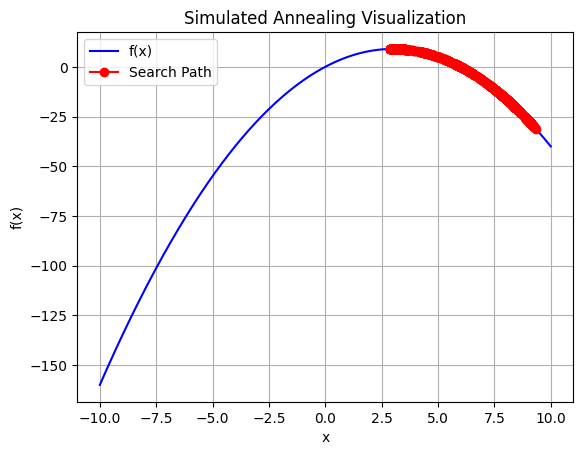

Best solution found: 2.992951459447977
Function value: 8.999950318076086


In [2]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return -(x - 3) ** 2 + 9

def simulated_annealing(max_iterations=1000, step_size=0.1, initial_temp=100, cooling_rate=0.99):
    current = random.uniform(-10, 10)
    current_value = f(current)
    temperature = initial_temp
    history = [current]

    for _ in range(max_iterations):
        neighbor = current + random.uniform(-step_size, step_size)
        neighbor_value = f(neighbor)
        delta = neighbor_value - current_value

        if delta > 0 or random.random() < math.exp(delta / temperature):
            current, current_value = neighbor, neighbor_value
            history.append(current)

        temperature *= cooling_rate

    return current, current_value, history

solution, value, history = simulated_annealing()

x = np.linspace(-10, 10, 400)
y = f(x)

plt.plot(x, y, label="f(x)", color="blue")
plt.title("Simulated Annealing Visualization")
plt.xlabel("x")
plt.ylabel("f(x)")

hx = history
hy = [f(h) for h in history]
plt.plot(hx, hy, "ro-", label="Search Path")

plt.legend()
plt.grid(True)
plt.show()

print("Best solution found:", solution)
print("Function value:", value)


f(x) → আমাদের যে ফাংশনটা maximize করতে হবে। এখানে এটা একটা simple quadratic function।

সর্বোচ্চ মান (maximum) পাওয়া যায় x = 3 এ।

current → শুরুতে এলোমেলো (random) একটা মান নেওয়া হয়।

Neighbor তৈরি → প্রতিবার current এর কাছাকাছি একটা নতুন মান (neighbor) বের করা হয়।

Delta = neighbor_value - current_value

যদি নতুন মানটা ভালো হয় (অর্থাৎ বড় হয়), সেটা আমরা নেব।

যদি খারাপ হয়, তাও মাঝে মাঝে নিই একটা probability অনুযায়ী (যেটা temperature এর উপর নির্ভর করে)।
👉 এইটাই Simulated Annealing-এর বিশেষত্ব → খারাপ solution মাঝে মাঝে নেওয়ার কারণে local maximum থেকে বের হতে পারে।

Temperature → শুরুতে অনেক বেশি, পরে ধীরে ধীরে কমতে থাকে (cooling)।

Temperature যত বেশি থাকবে, খারাপ solution নেওয়ার সম্ভাবনা তত বেশি।

Temperature কমে গেলে algorithm বেশি stable হয়ে যায়।

শেষে → algorithm প্রায় সব সময়েই global maximum (x=3, value=9) এর কাছাকাছি পৌঁছায়।